# Project: Synthetic Insurance Fraud & Cost-Sensitive AI

### 1. Overview

This notebook demonstrates an end-to-end workflow for detecting insurance fraud under real-world constraints: **data scarcity** and **financial impact**. It shifts the focus from standard accuracy metrics to **Cost Minimization**, ensuring that high-value fraud is prioritized over low-value false alarms.

### 2. Key Components

**A. Synthetic Data Engine & Fraud Injection**

* **Data Generation:** Creates a statistically valid dataset using a configuration schema to enforce distributions and constraints.
* **Behavioral Fraud:** Injects fraud based on three archetypes rather than random labeling:
    * **Opportunistic:** Driven by financial stress and "round number" bias.
    * **Premeditated:** Modeled via policy aging and claim timing interactions.
    * **Organized:** Deterministic mapping of external risk codes (Blacklists).

**B. Cost-Sensitive Modeling**

* **The Problem:** Standard models treat a missed £100k fraud the same as a missed £100 fraud.
* **The Solution:** We implement a **Financial Cost Function**:

$$\text{Cost} = (\text{False Negatives} \times 0.9 \times \text{SumInsured}) + (\text{False Positives} \times £100)$$

* **Implementation:** A custom wrapper optimizes decision thresholds to minimize this specific financial loss.

**C. Active Learning Simulation**

* **Scenario:** Simulates a "Cold Start" where no labeled data exists.
* **Strategy:** Instead of random labeling, an AI agent queries human reviewers for specific claims using strategies like **Uncertainty Sampling** and **Expected Cost Reduction** to maximize ROI on the labeling budget.

## 1. Data Schema Configuration
The `temp_list` variable below acts as the **Configuration Dictionary** for the dataset. Each item in the list represents a column and contains the following metadata used by the generator:

* **`dtype`**: The target data type (e.g., `Int64`, `bool`, `float64`).
* **`min` / `max`**: The hard boundaries for the data values.
* **`most_freq`**: Used as the **mean** for the Gaussian distribution to bias data towards realistic common values.
* **`description`**: A human-readable explanation of the column.
* **`semantic_hint`**: Indicates if the variable is `numeric` or `categorical`.

In [ ]:
temp_list = [
    {
    "claim_days_differenc": {
      "dtype": "Int64",
      "example": 0,
      "min": 1,
      "max": 9639,
      "most_freq": 1,
      "semantic_hint": "numeric",
      "description": "Days between the loss and reporting the loss"
    }
  },
  {
    "claim_loss_date_dom": {
      "dtype": "Int64",
      "example": 22,
      "min": 1,
      "max": 31,
      "most_freq": 1,
      "semantic_hint": "numeric",
      "description": "Claim loss date month"
    }
  },
  {
    "claim_loss_datet_to_policy_ply_icp_dt_delta": {
      "dtype": "Int64",
      "example": 20,
      "min": 0,
      "max": 2987,
      "most_freq": 1,
      "semantic_hint": "numeric",
      "description": "Days between claim reported, and the quote date of the policy"
    }
  },
  {
    "claim_loss_date_to_policy_str_date_delta": {
      "dtype": "Int64",
      "example": 20,
      "min": 0,
      "max": 1814,
      "most_freq": 3,
      "semantic_hint": "numeric",
      "description": "Days between the loss date, and the start of the policy year"
    }
  },
  {
    "claim_loss_type_ab": {
      "dtype": "bool",
      "example": 0,
      "min": 0,
      "max": 1,
      "most_freq": 0,
      "semantic_hint": "categorical",
      "description": "Claim loss type Flag"
    }
  },
  {
    "claim_loss_type_ad": {
      "dtype": "bool",
      "example": 1,
      "min": 0,
      "max": 1,
      "most_freq": 0,
      "semantic_hint": "categorical",
      "description": "Claim loss type Flag"
    }
  },
  {
    "claim_loss_type_al": {
      "dtype": "bool",
      "example": 0,
      "min": 0,
      "max": 1,
      "most_freq": 0,
      "semantic_hint": "categorical",
      "description": "Claim loss type Flag"
    }
  },
  {
    "claim_loss_type_eo": {
      "dtype": "bool",
      "example": 0,
      "min": 0,
      "max": 1,
      "most_freq": 0,
      "semantic_hint": "categorical",
      "description": "Claim loss type Flag"
    }
  },
  {
    "claim_loss_type_es": {
      "dtype": "bool",
      "example": 0,
      "min": 0,
      "max": 1,
      "most_freq": 0,
      "semantic_hint": "categorical",
      "description": "Claim loss type Flag"
    }
  },
  {
    "claim_loss_type_ew": {
      "dtype": "bool",
      "example": 0,
      "min": 0,
      "max": 1,
      "most_freq": 0,
      "semantic_hint": "categorical",
      "description": "Claim loss type Flag"
    }
  },
  {
    "claim_loss_type_fi": {
      "dtype": "bool",
      "example": 0,
      "min": 0,
      "max": 1,
      "most_freq": 0,
      "semantic_hint": "categorical",
      "description": "Claim loss type Flag"
    }
  },
  {
    "claim_loss_type_fl": {
      "dtype": "bool",
      "example": 0,
      "min": 0,
      "max": 1,
      "most_freq": 0,
      "semantic_hint": "categorical",
      "description": "Claim loss type Flag"
    }
  },
  {
    "claim_loss_type_gm": {
      "dtype": "bool",
      "example": 0,
      "min": 0,
      "max": 1,
      "most_freq": 0,
      "semantic_hint": "categorical",
      "description": "Claim loss type Flag"
    }
  },
  {
    "claim_loss_type_im": {
      "dtype": "bool",
      "example": 0,
      "min": 0,
      "max": 1,
      "most_freq": 0,
      "semantic_hint": "categorical",
      "description": "Claim loss type Flag"
    }
  },
  {
    "claim_loss_type_lb": {
      "dtype": "bool",
      "example": 0,
      "min": 0,
      "max": 1,
      "most_freq": 0,
      "semantic_hint": "categorical",
      "description": "Claim loss type Flag"
    }
  },
  {
    "claim_loss_type_mc": {
      "dtype": "bool",
      "example": 0,
      "min": 0,
      "max": 1,
      "most_freq": 0,
      "semantic_hint": "categorical",
      "description": "Claim loss type Flag"
    }
  },
  {
    "claim_loss_type_md": {
      "dtype": "bool",
      "example": 0,
      "min": 0,
      "max": 1,
      "most_freq": 0,
      "semantic_hint": "categorical",
      "description": "Claim loss type Flag"
    }
  },
  {
    "claim_loss_type_rl": {
      "dtype": "bool",
      "example": 0,
      "min": 0,
      "max": 1,
      "most_freq": 0,
      "semantic_hint": "categorical",
      "description": "Claim loss type Flag"
    }
  },
  {
    "claim_loss_type_st": {
      "dtype": "bool",
      "example": 0,
      "min": 0,
      "max": 1,
      "most_freq": 0,
      "semantic_hint": "categorical",
      "description": "Claim loss type Flag"
    }
  },
  {
    "claim_loss_type_th": {
      "dtype": "bool",
      "example": 0,
      "min": 0,
      "max": 1,
      "most_freq": 0,
      "semantic_hint": "categorical",
      "description": "Claim loss type Flag"
    }
  },
  {
    "claim_number": {
      "dtype": "Int64",
      "example": "1E+08",
      "min": "1E+08",
      "max": "2E+08",
      "most_freq": "1E+08",
      "semantic_hint": "numeric",
      "description": "Claim ID"
    }
  },
  {
    "claim_report_date_to_policy_ori_qte_dt_delta": {
      "dtype": "Int64",
      "example": 20,
      "min": 0,
      "max": 2988,
      "most_freq": 707,
      "semantic_hint": "numeric",
      "description": "Days between the loss date, and the start of the policy year"
    }
  },
  {
    "sum_insured": {
      "dtype": "Int64",
      "example": 30295,
      "min": -1,
      "max": 480214,
      # "most_freq": -1,
      "semantic_hint": "numeric",
      "description": "The total amount insured for the contents of a property."
    }
  },
  {
    "reinstatement_value": {
      "dtype": "Int64",
      "example": 158564,
      "min": 0,
      "max": 3854554,
      # "most_freq": -1,
      "semantic_hint": "numeric",
      "description": "Experian - Property reinstatement value"
    }
  },
  {
    "credit_risk_score": {
      "dtype": "Int64",
      "example": -1,
      "min": -1,
      "max": 1344,
      # "most_freq": -1,
      "semantic_hint": "numeric",
      "description": "Experian - Credit Score"
    }
  },
  {
    "total_active_associate_cai": {
      "dtype": "Int64",
      "example": -1,
      "min": -1,
      "max": 9,
      "most_freq": 2,
      "semantic_hint": "numeric",
      "description": "Experian - Total active credit accounts"
    }
  },
  {
    "barriers_wide_score": {
      "dtype": "float64",
      "example": -0.963,
      "min": -8.45,
      "max": 7.527,
      "most_freq": -1,
      "semantic_hint": "numeric",
      "description": "Indices of multiple deprivation - wider barriers score"
    }
  },
  {
    "children_population": {
      "dtype": "Int64",
      "example": 369,
      "min": 0,
      "max": 1358,
      # "most_freq": -1,
      "semantic_hint": "numeric",
      "description": "Indices of multiple deprivation - total children population"
    }
  },
  {
    "insurance_indicator": {
      "dtype": "bool",
      "example": 0,
      "min": 0,
      "max": 1,
      "most_freq": 1,
      "semantic_hint": "categorical",
      "description": "Does GDW recognise the policyholder as having a home insurance policy"
    }
  },
  {
    "oc_code": {
      "dtype": "Int64",
      "example": 1,
      "min": 1,
      "max": 3,
      "most_freq": 3,
      "semantic_hint": "categorical",
      "description": "SIRA Red/Amber/Green Flag"
    }
  },
  {
    "policy_api": {
      "dtype": "Int64",
      "example": 2,
      "min": 1,
      "max": 4,
      "most_freq": 1,
      "semantic_hint": "numeric",
      "description": "Number of policyholders"
    }
  },
  {
    "policy_claim_free_year": {
      "dtype": "Int64",
      "example": 0,
      "min": 0,
      "max": 7,
      "most_freq": 5,
      "semantic_hint": "numeric",
      "description": "Number of claim free years"
    }
  },
  {
    "policy_cld_cst1_aggregate": {
      "dtype": "Int64",
      "example": 30,
      "min": 30,
      "max": 90,
      "most_freq": 53,
      "semantic_hint": "numeric",
      "description": "Oldest policyholder age"
    }
  },
  {
    "policy_ply_icp_dt_to_cust_cst_brt_dt_delta": {
      "dtype": "Int64",
      "example": 11220,
      "min": 0,
      "max": 38523,
      "most_freq": 11220,
      "semantic_hint": "numeric",
      "description": "Customer age at policy inception date"
    }
  },
  {
    "prop_prv_isn_cne": {
      "dtype": "Int64",
      "example": 0,
      "min": 0,
      "max": 60,
      "most_freq": 30,
      "semantic_hint": "numeric",
      "description": "How many years has the policyholder had contents insurance"
    }
  },
  {
    "risk_band1": {
      "dtype": "Int64",
      "example": 16,
      "min": -1,
      "max": 30,
      "most_freq": 9,
      "semantic_hint": "numeric",
      "description": "Geographic theft risk band"
    }
  },
  {
    "risk_band2": {
      "dtype": "Int64",
      "example": 5,
      "min": -1,
      "max": 30,
      "most_freq": 5,
      "semantic_hint": "numeric",
      "description": "Geographic personal belongings risk band"
    }
  },
  {
    "risk_band3": {
      "dtype": "Int64",
      "example": 12,
      "min": -1,
      "max": 30,
      "most_freq": 4,
      "semantic_hint": "numeric",
      "description": "Geographic specified items risk band"
    }
  },
  {
    "building_gutter_height": {
      "dtype": "float64",
      "example": 4.6,
      "min": 0,
      "max": 20,
      # "most_freq": -1,
      "semantic_hint": "numeric",
      "description": "WF - Modelled gutter height of property"
    }
  },
  {
    "ridge_height": {
      "dtype": "float64",
      "example": 6.9,
      "min": 0,
      "max": 20,
      # "most_freq": -1,
      "semantic_hint": "numeric",
      "description": "WF - Modelled roof Ridge Height of Property"
    }
  },
  {
    "floor_space": {
      "dtype": "Int64",
      "example": 63,
      "min": 0,
      "max": 300,
      # "most_freq": -1,
      "semantic_hint": "numeric",
      "description": "WF - Modelled dwelling floor space"
    }
  },
  {
    "nearest_tree_dist": {
      "dtype": "float64",
      "example": 13.09,
      "min": 00,
      "max": 99.99,
      # "most_freq": -1,
      "semantic_hint": "numeric",
      "description": "WF - Property distance to nearest tree"
    }
  },
  {
    "year_built_of_propery": {
      "dtype": "Int64",
      "example": 1996,
      "min": 1850,
      "max": 2023,
      "most_freq": 1900,
      "semantic_hint": "numeric",
      "description": "WF - Modelled property year built"
    }
  },
  # {
  #   "target": {
  #     "dtype": "bool",
  #     "example": 1,
  #     "min": 0,
  #     "max": 1,
  #     "most_freq": 0,
  #     "semantic_hint": "categorical",
  #     "description": "Target Variable"
  #   }
  # }
]

In [ ]:
len(temp_list)

43

In [ ]:
col_with__1 = ['sum_insured', 'reinstatement_value', 'credit_risk_score', 'children_population',
               'barriers_wide_score', 'building_gutter_height', 'ridge_height', 'floor_space', 'nearest_tree_dist']

In [ ]:
len(col_with__1)

9

## 2. Synthetic Data Generator Function
The `generate_synthetic_data` function is the core engine of this notebook. It transforms the schema defined above into a pandas DataFrame.

### Algorithm Logic
1.  **Grouped One-Hot Encoding**:
    * It identifies all columns starting with `claim_loss_type_`.
    * It generates a random index for each row and sets exactly one of these columns to `1` (True) while keeping others `0` (False), ensuring mutual exclusivity.

2.  **Numeric & Boolean Generation**:
    * Iterates through the remaining schema items.
    * **Distribution**:
        * If `most_freq` is provided, it is used as the **Mean**.
        * If missing, the **Mean** is the midpoint between `min` and `max`.
        * **Standard Deviation** is calculated as $\frac{Max - Min}{6}$, ensuring ~99.7% of values fall within the range.
    * **Constraints**: Values are clipped using `np.clip` to strictly enforce the `min` and `max` limits.
    * **Rounding**: Values are rounded and cast to the specified `dtype`.

In [5]:
import pandas as pd
import numpy as np

def generate_synthetic_data(schema_list, num_rows=95000):
    """
    Generates a synthetic DataFrame based on a schema list dictionary.

    Logic:
    1. Identifies 'One-Hot' groups (columns sharing a prefix like 'claim_loss_type_').
    2. Applies Gaussian distribution for numeric fields:
       - If 'most_freq' exists: Mean = most_freq
       - If 'most_freq' missing: Mean = (min + max) / 2
       - Std Dev is derived as (max - min) / 6 (covering ~99.7% of the range).
    """

    data = {}

    # 1. Identify One-Hot Encoding Groups
    # We look for boolean columns with similar prefixes (specifically 'claim_loss_type_')
    one_hot_prefix = "claim_loss_type_"
    one_hot_cols = [
        list(item.keys())[0]
        for item in schema_list
        if list(item.keys())[0].startswith(one_hot_prefix)
    ]

    # Generate One-Hot Data globally for consistency (mutually exclusive)
    if one_hot_cols:
        print(f"Generating One-Hot group for: {one_hot_cols}")
        # Randomly assign one category per row
        random_indices = np.random.randint(0, len(one_hot_cols), size=num_rows)

        for i, col_name in enumerate(one_hot_cols):
            # 1 if selected, 0 otherwise
            data[col_name] = (random_indices == i).astype(int)

    # 2. Process all other columns
    for item in schema_list:
        col_name = list(item.keys())[0]
        metadata = item[col_name]

        # Skip if already generated (i.e., it was part of the One-Hot group)
        if col_name in data:
            continue

        # Parse Min/Max (handle scientific notation strings like '1E+08')
        min_val = float(metadata.get('min'))
        max_val = float(metadata.get('max'))
        dtype = metadata.get('dtype', 'float64')

        # Determine Gaussian Parameters
        if 'most_freq' in metadata:
            # Case A: most_freq is present -> Use it as Mean
            mean = float(metadata['most_freq'])
            # Heuristic: If mean is at the edge (min), set std so the tail covers the range
            # We use (max - min) / 6 as a standard robust spread
            std_dev = (max_val - min_val) / 6
        else:
            # Case B: most_freq commented out (missing) -> Use Min-Max midpoint
            mean = (min_val + max_val) / 2
            std_dev = (max_val - min_val) / 6

        # Handle case where max == min (constant value)
        if std_dev == 0:
            std_dev = 0.0001

        # Generate Data
        values = np.random.normal(loc=mean, scale=std_dev, size=num_rows)

        # Clip to ensure hard min/max constraints
        values = np.clip(values, min_val, max_val)

        # Apply Data Types
        if dtype == 'Int64' or dtype == 'int':
            data[col_name] = np.round(values).astype(np.int64)
        elif dtype == 'bool':
            # For boolean, we treat > 0.5 as True (though usually treated as categorical)
            data[col_name] = (np.round(values) >= 1).astype(int)
        else:
            data[col_name] = values

    # Create DataFrame
    df = pd.DataFrame(data)

    # Ensure columns are ordered as per the input list
    ordered_cols = [list(x.keys())[0] for x in schema_list]
    df = df[ordered_cols]

    return df

# --- Execution Block ---

# 1. Generate Data
print("Generating 95,000 rows...")
df_result = generate_synthetic_data(temp_list, num_rows=95000)

# 2. Export to CSV
file_name = "synthetic_insurance_claims.csv"
df_result.to_csv(file_name, index=False)
print(f"Successfully created {file_name} with shape {df_result.shape}")

KeyboardInterrupt: 

In [ ]:
df_result.columns

Index(['claim_days_differenc', 'claim_loss_date_dom',
       'claim_loss_datet_to_policy_ply_icp_dt_delta',
       'claim_loss_date_to_policy_str_date_delta', 'claim_loss_type_ab',
       'claim_loss_type_ad', 'claim_loss_type_al', 'claim_loss_type_eo',
       'claim_loss_type_es', 'claim_loss_type_ew', 'claim_loss_type_fi',
       'claim_loss_type_fl', 'claim_loss_type_gm', 'claim_loss_type_im',
       'claim_loss_type_lb', 'claim_loss_type_mc', 'claim_loss_type_md',
       'claim_loss_type_rl', 'claim_loss_type_st', 'claim_loss_type_th',
       'claim_number', 'claim_report_date_to_policy_ori_qte_dt_delta',
       'sum_insured', 'reinstatement_value', 'credit_risk_score',
       'total_active_associate_cai', 'barriers_wide_score',
       'children_population', 'insurance_indicator', 'oc_code', 'policy_api',
       'policy_claim_free_year', 'policy_cld_cst1_aggregate',
       'policy_ply_icp_dt_to_cust_cst_brt_dt_delta', 'prop_prv_isn_cne',
       'risk_band1', 'risk_band2', 'risk_ban

In [ ]:
import numpy as np

for col in col_with__1:
    # Identify 1% random indices
    mask = df_result.sample(frac=0.01).index

    # Update values while keeping original dtype (casting -1 to col type)
    df_result.loc[mask, col] = df_result[col].dtype.type(-1)

# Safety check: If any row ended up with -1 across ALL target columns,
# restore one random column in that row to its original/mean value (extremely rare at 1% rate)
all_minus_one = (df_result[col_with__1] == -1).all(axis=1)
if all_minus_one.any():
    for idx in df_result.index[all_minus_one]:
        random_col = np.random.choice(col_with__1)
        # Flip this one back to a non -1 value (e.g., the column's mean or a valid example)
        df_result.loc[idx, random_col] = df_result[random_col].mean()

In [ ]:
# Assuming col_with__1 is your list of columns
for col in col_with__1:
    count = (df_result[col] == -1).sum()
    print(f"Number of -1 values in '{col}': {count}")

Number of -1 values in 'sum_insured': 1067
Number of -1 values in 'reinstatement_value': 950
Number of -1 values in 'credit_risk_score': 1074
Number of -1 values in 'children_population': 950
Number of -1 values in 'barriers_wide_score': 950
Number of -1 values in 'building_gutter_height': 950
Number of -1 values in 'ridge_height': 950
Number of -1 values in 'floor_space': 950
Number of -1 values in 'nearest_tree_dist': 950


In [ ]:
for col in col_with__1:
    print(f"\n{'='*40}")
    print(f"SUMMARY FOR: {col}")
    print(f"{'='*40}")

    # Calculate counts and percentages
    counts = df_result[col].value_counts()
    percentages = df_result[col].value_counts(normalize=True) * 100

    # Combine into summary DataFrame
    summary = pd.DataFrame({
        'Frequency': counts,
        'Percentage (%)': percentages
    })

    # Display the top 10 most frequent values (to avoid flooding the console)
    print(summary.head(10))


SUMMARY FOR: sum_insured
             Frequency  Percentage (%)
sum_insured                           
-1                1067        1.123158
 480214            135        0.142105
 234261              5        0.005263
 241710              5        0.005263
 237709              5        0.005263
 258007              5        0.005263
 286966              5        0.005263
 281045              5        0.005263
 303313              5        0.005263
 189346              5        0.005263

SUMMARY FOR: reinstatement_value
                     Frequency  Percentage (%)
reinstatement_value                           
-1                         950        1.000000
 3854554                   141        0.148421
 0                         120        0.126316
 1251177                     4        0.004211
 1382765                     3        0.003158
 1991522                     3        0.003158
 2223779                     3        0.003158
 1979517                     3        0.003158
 1

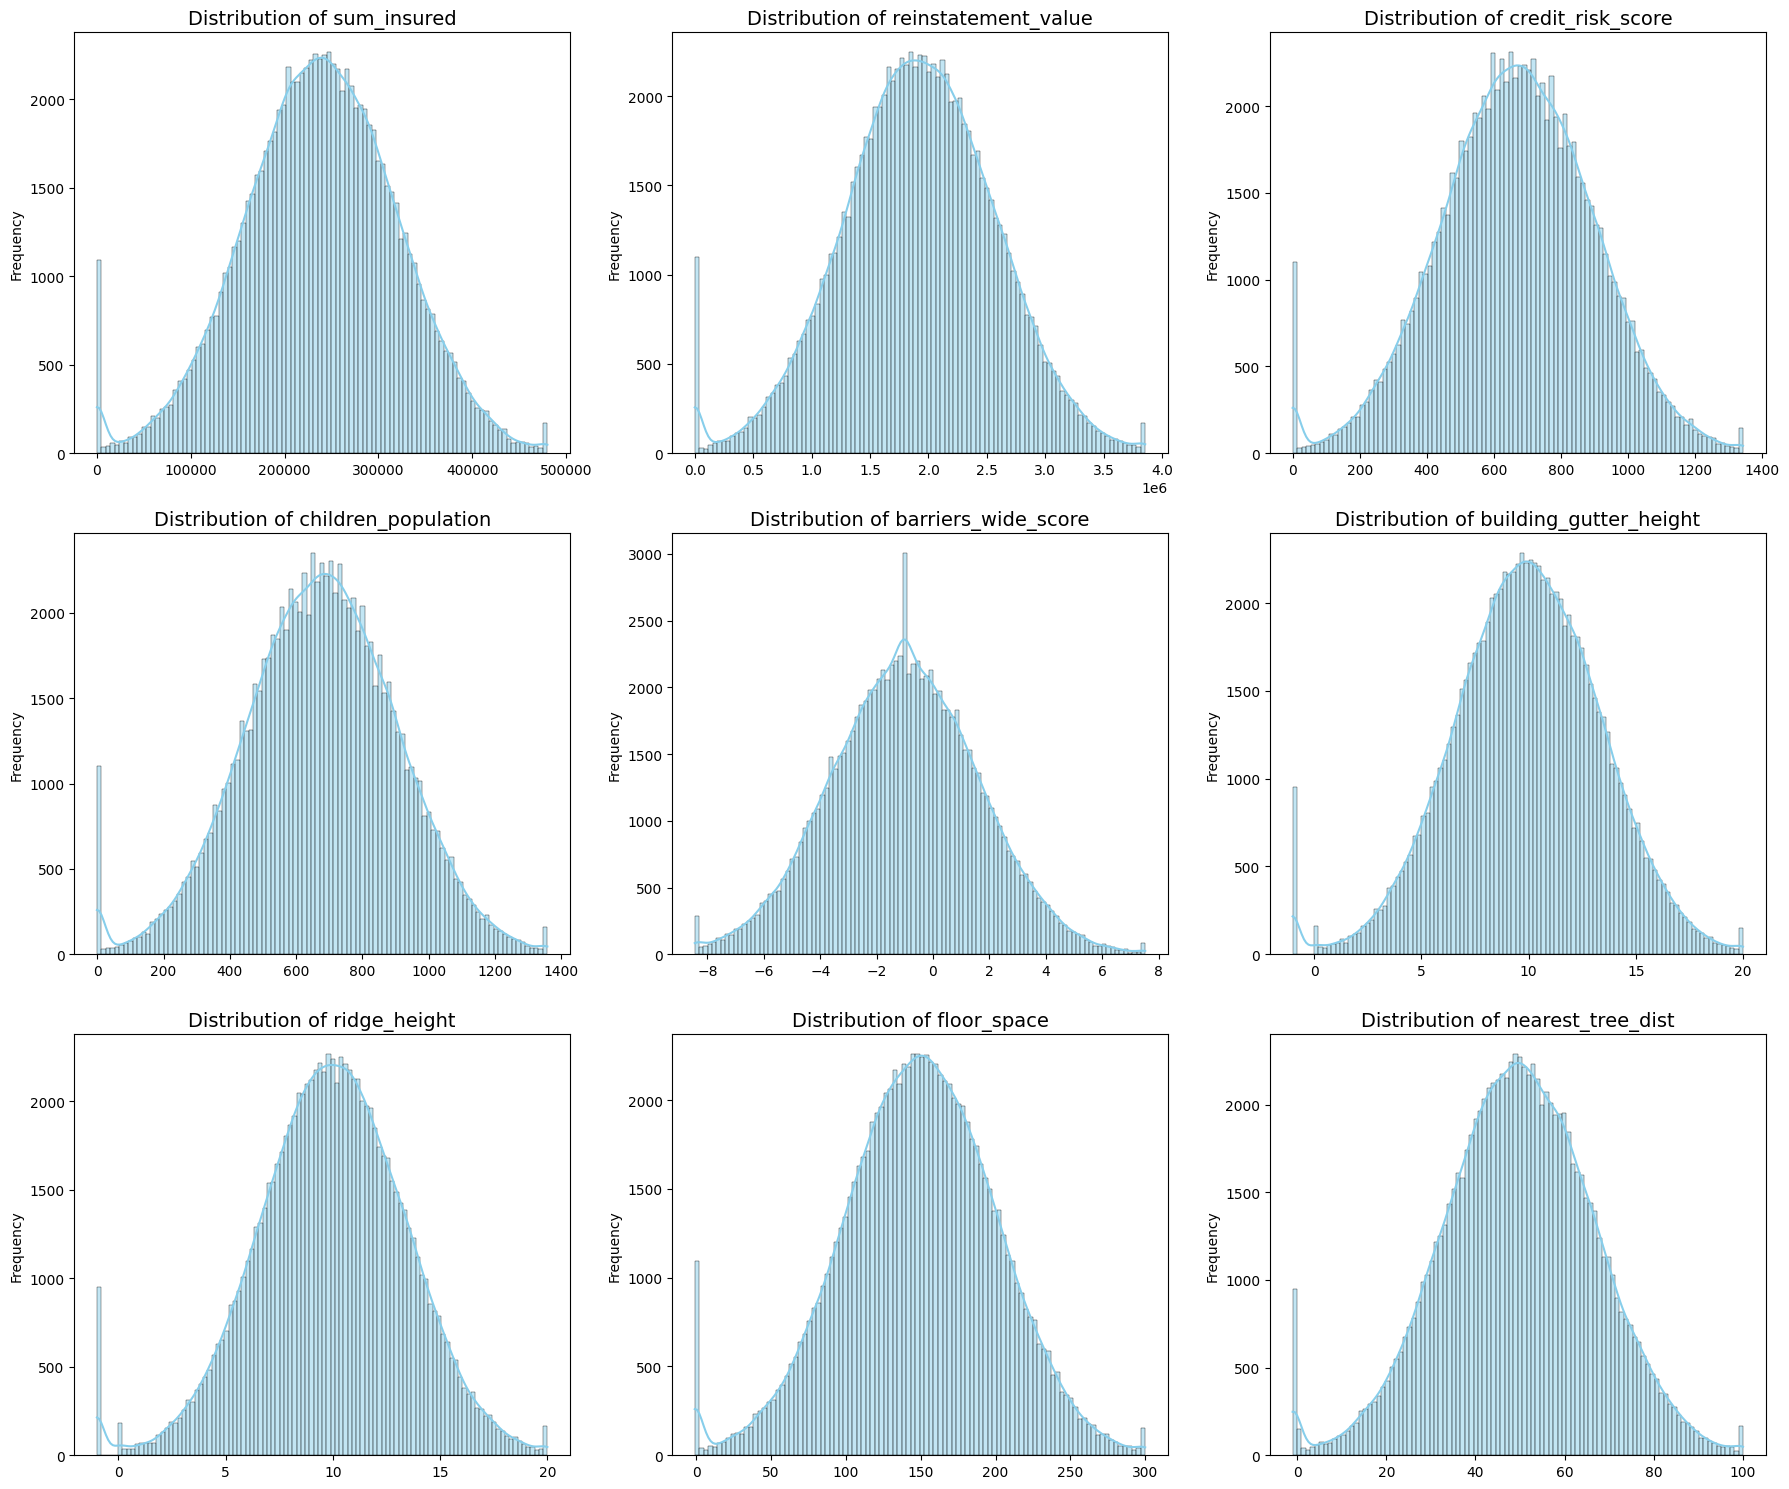

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define your column list
col_with__1 = [
    'sum_insured', 'reinstatement_value', 'credit_risk_score',
    'children_population', 'barriers_wide_score', 'building_gutter_height',
    'ridge_height', 'floor_space', 'nearest_tree_dist'
]

# Set up the figure and axes (3 rows by 3 columns)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Loop through the columns and create the plots
for i, col in enumerate(col_with__1):
    sns.histplot(df_result[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

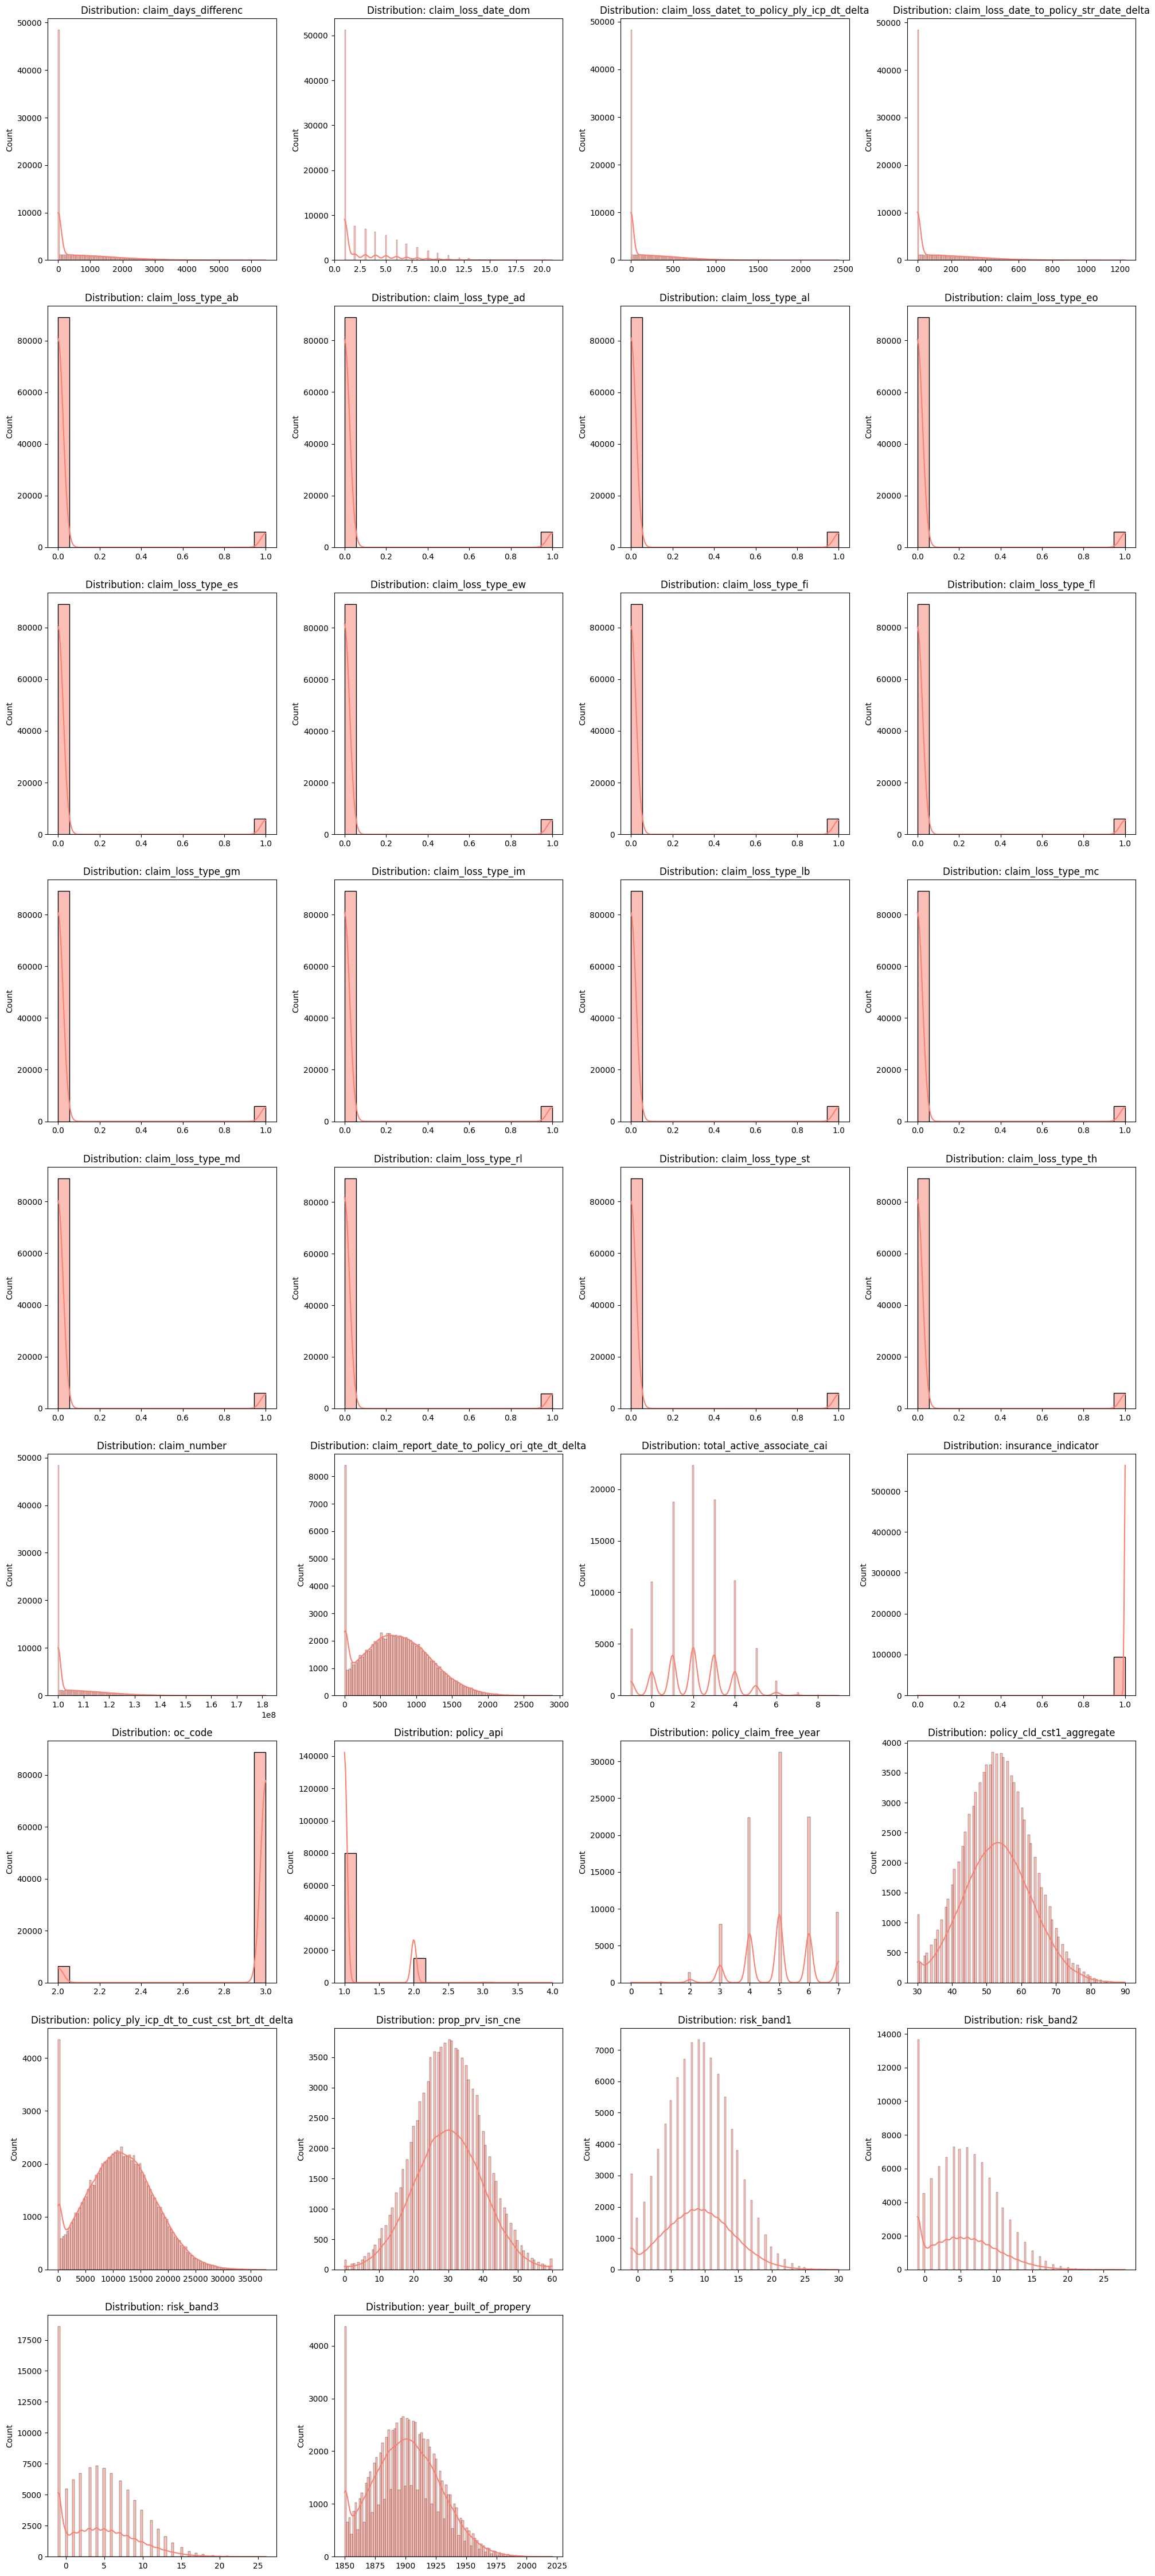

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Define the original list to exclude
col_with__1 = [
    'sum_insured', 'reinstatement_value', 'credit_risk_score', 'children_population',
    'barriers_wide_score', 'building_gutter_height', 'ridge_height',
    'floor_space', 'nearest_tree_dist'
]

# 2. Get the list of remaining columns
# We use df_result.columns to get the current order and filter out the ones already plotted
remaining_cols = [col for col in df_result.columns if col not in col_with__1]

# 3. Calculate grid dimensions (e.g., 4 columns wide)
n_cols = 4
n_rows = math.ceil(len(remaining_cols) / n_cols)

# 4. Create the plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(remaining_cols):
    # Plot histogram with KDE for each remaining column
    sns.histplot(df_result[col], kde=True, ax=axes[i], color='salmon')
    axes[i].set_title(f'Distribution: {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

# Remove any empty subplots if the grid is larger than the number of columns
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 🕵️‍♂️ Advanced Fraud Label Generation Engine

This section implements a multi-archetype fraud simulation to generate highly realistic, non-linear fraud labels. Unlike simple random sampling or linear assignments, this engine creates a "ground truth" based on complex behavioral patterns found in real insurance claims.

### 🏗️ The Three Fraud Archetypes
We model fraud using three distinct profiles to ensure the dataset captures varied risk behaviors:

1.  **Archetype A: The Opportunist (Financial Greed)**
    * **Logic:** Triggered by high **over-insurance ratios** (Sum Insured vs. Reinstatement Value), **round-number bias** in claims, and **missing credit history**.
    * **Non-Linearity:** Uses a "3-way multiplicative gate." The risk doesn't just add up; it spikes exponentially only when all three factors intersect.

2.  **Archetype B: The Premeditated Fraudster (Timing Signals)**
    * **Logic:** Focuses on temporal anomalies. Uses a **Bimodal Gaussian Kernel** to catch claims filed *immediately* (0–5 days) or with a *staged delay* (~120 days).
    * **Non-Linearity:** A linear model cannot draw a single line to capture two separate peaks of risk; this forces the model to learn complex temporal distributions.

3.  **Archetype C: The Organized Ring (Network & Geography)**
    * **Logic:** Leverages geographic risk bands, SIRA red flags, and missing property survey data (fictitious properties).
    * **Non-Linearity:** Calculates a **Product of Risk Bands** (Degree-3 polynomial). High risk in one area is common; high risk across three independent geographic factors is a ring signal.

---

### 🧠 Why Linear Models (Logistic Regression) Will Fail
The labels generated here are designed to challenge standard algorithms. A simple linear classifier will struggle because:
* **XOR-Style Conditions:** High-value claims are only fraudulent *if* credit data is missing. Individually, these features are "normal."
* **The Sentinel Effect:** We treat `-1` (missing data) not as noise, but as a feature. The meaning of "missing" changes depending on the archetype.
* **Perfect Storm Interactions:** We introduce a cross-archetype multiplier where a claim firing on all three profiles receives a massive, non-linear boost in probability.

### 🛠️ Technical Robustness & Bug Fixes
* **Division by Zero Handling:** Implemented a floor for `reinstatement_value` to prevent `NaN` propagation during ratio calculations.
* **Sentinel Separation:** Automatically detects `-1` values, creates binary "missing" flags, and uses median-imputation for the mathematical scoring to maintain array integrity.
* **Robust Scaling:** Uses **99.5th percentile clipping** for min-max scaling to ensure that extreme outliers don't squash the rest of the probability distribution into a narrow, unusable range.
* **Calibrated Noise:** A Gaussian jitter is added to the final score to simulate the "gray area" of real-world data, preventing the model from finding a perfectly "clean" mathematical split.

# Data generation with 3% fraud in universe

=== Fraud Engine Statistics ===
Target Fraud Rate  : 3.00%
Actual Fraud Rate  : 3.00%
Prob Score > 0.70  : 17.74%
Prob Score > 0.90  : 14.64%
Score Mean / Std   : 0.4153 / 0.3118
NaN in score       : 0 (should be 0)


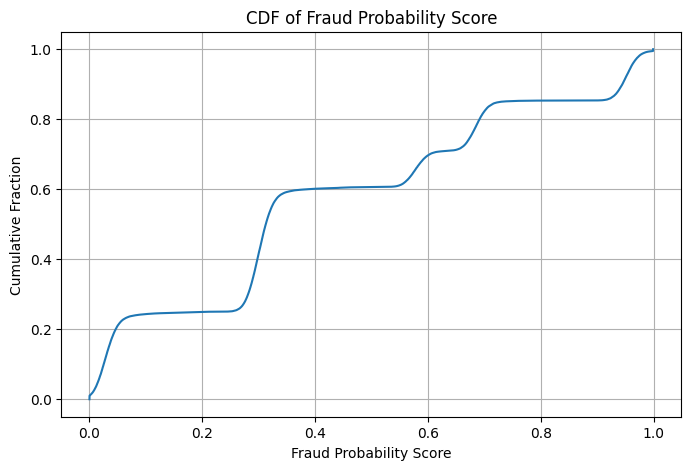


=== Recommended Thresholds ===
9% highest-risk threshold: 0.9446
5% highest-risk threshold: 0.9600
3% highest-risk threshold: 0.9680
1% highest-risk threshold: 0.9837
Threshold used: 0.9680
fraud_label
0    0.969989
1    0.030011
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
import numpy as np

def generate_fraud_labels_advanced(df, target_fraud_rate=0.03, random_seed=42):
    """
    Advanced fraud label generation for insurance claims.

    THREE FRAUD ARCHETYPES:
      A. Opportunistic  – Financial greed: over-insurance ratio + round numbers + missing credit
      B. Premeditated   – Timing signals: bimodal Gaussian kernel (very early OR staged delay)
      C. Organized Ring – Network signals: multiplicative risk bands, missing property data, SIRA flag

    WHY LINEAR MODELS FAIL ON THIS:
    ─────────────────────────────────────────────────────────────────────────────
    1. BIMODAL RISK CURVE (Archetype B):
       Fraud peaks at 0–5 days AND again at ~120 days. Normal claims sit in the middle.
       A linear model can only draw one threshold — it will always miss one peak.

    2. MULTIPLICATIVE 3-WAY GATE (Archetype A, Interaction I1):
       Fraud fires when: (over_insured=True) AND (credit_missing=True) AND (round_number=True).
       In feature space this is a corner of a cube — unreachable by a hyperplane.

    3. PRODUCT OF RISK BANDS (Archetype C):
       risk_band1 * risk_band2 * risk_band3 is a degree-3 polynomial.
       Logistic regression with linear features cannot capture this.

    4. XOR-STYLE SHADOW PROFILE (Interaction I2):
       High sum_insured is only fraud IF multiple Experian fields are missing.
       Neither condition alone is sufficient. Classic XOR — provably non-linear.

    5. CONDITIONAL -1 SENTINEL MEANING:
       The -1 flag is only a strong fraud signal when combined with other archetype scores.
       It has ZERO marginal effect if the claim is otherwise normal — the relationship is
       interaction-dependent, not additive.
    ─────────────────────────────────────────────────────────────────────────────

    BUG FIX vs. original:
    The original function computed `sum_insured / (reinstatement_value + 1.0)` without
    handling -1 sentinels. When reinstatement_value = -1, the denominator becomes 0.0,
    causing division by zero → NaN. np.percentile() on any NaN array returns NaN,
    which propagates to ALL rows → all fraud_probability_score = NaN → all labels = 0.

    This version separates sentinel handling completely before any computation.
    """

    temp = df.copy()
    rng = np.random.RandomState(random_seed)
    n = len(temp)

    # =========================================================================
    # STEP 0: SENTINEL -1 HANDLING
    # -1 in this dataset = "bureau returned no data" (Experian, property surveyors).
    # Strategy:
    #   (a) Create binary "is_missing" flags — these ARE fraud signals.
    #   (b) Replace -1 with the column's median of VALID values for all ratio math.
    # =========================================================================

    sentinel_cols = [
        'sum_insured', 'reinstatement_value', 'credit_risk_score',
        'children_population', 'barriers_wide_score',
        'building_gutter_height', 'ridge_height',
        'floor_space', 'nearest_tree_dist'
    ]

    missing_flags = {}  # col -> array of 0.0/1.0
    clean = {}          # col -> array with -1 replaced by valid median

    for col in sentinel_cols:
        if col in temp.columns:
            raw = temp[col].astype(float).values
            is_missing = (raw == -1.0)
            missing_flags[col] = is_missing.astype(float)

            valid_vals = raw[~is_missing]
            fill_val = float(np.median(valid_vals)) if len(valid_vals) > 0 else 0.0
            cleaned = raw.copy()
            cleaned[is_missing] = fill_val
            clean[col] = cleaned

    def get_clean(col):
        """Returns sentinel-cleaned array; falls back to raw column."""
        if col in clean:
            return clean[col]
        elif col in temp.columns:
            return temp[col].astype(float).values
        return np.zeros(n)

    def standardize(col):
        """Z-score on sentinel-cleaned values."""
        vals = get_clean(col)
        mu, sigma = vals.mean(), vals.std()
        return (vals - mu) / (sigma + 1e-6)

    # =========================================================================
    # ARCHETYPE A: OPPORTUNISTIC FRAUD
    # Driver: Financial motive — over-insurance, round-number bias, missing credit.
    # Key non-linearity: 3-way multiplicative gate.
    # =========================================================================

    score_A = np.zeros(n)

    # A1. Over-insurance ratio (clean values — no division by zero)
    if 'sum_insured' in clean and 'reinstatement_value' in clean:
        si   = clean['sum_insured']
        rv   = np.maximum(clean['reinstatement_value'], 5000.0)  # floor to avoid /0
        ratio = si / rv
        # Exponential amplification above 1.3× — non-linear in ratio
        score_A += np.where(ratio > 1.3, np.exp((ratio - 1.3) * 2.5) - 1.0, 0.0)

    # A2. Round-number bias (fraudsters invent round figures)
    if 'sum_insured' in clean:
        si_int = clean['sum_insured'].astype(int)
        round_1000 = (si_int % 1000 == 0).astype(float)
        round_500  = ((si_int % 500 == 0) & (si_int % 1000 != 0)).astype(float)
        score_A += round_1000 * 0.9 + round_500 * 0.4

    # A3. Missing credit score is a moderate risk on its own
    if 'credit_risk_score' in missing_flags:
        score_A += missing_flags['credit_risk_score'] * 0.6

    # A4. KEY NON-LINEARITY: 3-way gate
    # Over-insured AND missing credit AND round number → multiplicative spike
    if ('sum_insured' in clean and 'reinstatement_value' in clean
            and 'credit_risk_score' in missing_flags):
        si  = clean['sum_insured']
        rv  = np.maximum(clean['reinstatement_value'], 5000.0)
        over_insured = (si / rv > 1.3).astype(float)
        miss_credit  = missing_flags['credit_risk_score']
        round_num    = (clean['sum_insured'].astype(int) % 1000 == 0).astype(float)
        # Product: all three must be true → corner of feature cube
        score_A += over_insured * miss_credit * round_num * 4.0

    # =========================================================================
    # ARCHETYPE B: PREMEDITATED FRAUD
    # Driver: Timing — bimodal risk (immediate claim OR staged ~120-day delay).
    # Key non-linearity: bimodal Gaussian — a linear threshold cuts one peak only.
    # =========================================================================

    score_B = np.zeros(n)

    if 'claim_days_differenc' in temp.columns:
        days = temp['claim_days_differenc'].astype(float).values

        # Peak 1: Immediate claim (0–5 days after loss) — "set up" fraud
        score_B += 2.8 * np.exp(-(days ** 2) / 18.0)

        # Peak 2: Staged delay (~120 days) — fraudster waits to seem legitimate
        score_B += 1.5 * np.exp(-((days - 120.0) ** 2) / 600.0)

        # (Normal claims report in 6–40 days — naturally low on both Gaussians)

    # B2. New policy + immediate claim: multiplicative AND gate
    if ('claim_loss_date_to_policy_str_date_delta' in temp.columns
            and 'claim_days_differenc' in temp.columns):
        policy_age = temp['claim_loss_date_to_policy_str_date_delta'].astype(float).values
        new_policy   = (policy_age < 60).astype(float)
        fast_claim   = (temp['claim_days_differenc'].astype(float).values < 5).astype(float)
        # AND — neither alone is strong; together they are decisive
        score_B += new_policy * fast_claim * 3.5

    # B3. Claim before/at inception (icp_delta very small → temporal impossibility)
    if 'claim_loss_datet_to_policy_ply_icp_dt_delta' in temp.columns:
        icp_delta = temp['claim_loss_datet_to_policy_ply_icp_dt_delta'].astype(float).values
        score_B += np.where(icp_delta < 5, 2.5, 0.0)

    # =========================================================================
    # ARCHETYPE C: ORGANIZED RING
    # Driver: Network/geography signals — risk bands interact multiplicatively,
    # fictitious properties have missing survey data, SIRA red flags.
    # Key non-linearity: product of three risk bands (degree-3 polynomial).
    # =========================================================================

    score_C = np.zeros(n)

    # C1. Product of geographic risk bands (non-linear in all three)
    if all(c in temp.columns for c in ['risk_band1', 'risk_band2', 'risk_band3']):
        rb1 = np.maximum(0.0, temp['risk_band1'].astype(float).values) / 30.0
        rb2 = np.maximum(0.0, temp['risk_band2'].astype(float).values) / 30.0
        rb3 = np.maximum(0.0, temp['risk_band3'].astype(float).values) / 30.0
        # Triple product — cannot be expressed as a linear combination of rb1, rb2, rb3
        score_C += rb1 * rb2 * rb3 * 5.0

    # C2. SIRA red flag (oc_code == 1) — deterministic blacklist signal
    if 'oc_code' in temp.columns:
        red_flag = (temp['oc_code'] == 1).astype(float)
        score_C += red_flag * 2.8

    # C3. Missing property survey data (fictitious properties)
    if 'floor_space' in missing_flags and 'ridge_height' in missing_flags:
        both_missing = missing_flags['floor_space'] * missing_flags['ridge_height']
        score_C += both_missing * 2.2  # AND gate: both missing = organized ring

    # C4. Theft claim type in high-risk geography (conditional interaction)
    if 'claim_loss_type_th' in temp.columns and 'risk_band1' in temp.columns:
        theft     = temp['claim_loss_type_th'].astype(float).values
        high_geo  = (temp['risk_band1'].astype(float).values > 20).astype(float)
        score_C  += theft * high_geo * 1.8  # AND: theft AND high-risk area

    # =========================================================================
    # CROSS-ARCHETYPE INTERACTIONS
    # These guarantee that no linear combination of individual features can
    # reproduce the decision boundary. The decision region is a union of
    # non-convex, non-linearly-separable zones in feature space.
    # =========================================================================

    # I1. "Perfect Storm" — all three archetypes fire simultaneously
    # Product of clipped archetype scores → 3-way interaction
    norm_A = np.minimum(score_A, 3.0) / 3.0
    norm_B = np.minimum(score_B, 3.0) / 3.0
    norm_C = np.minimum(score_C, 3.0) / 3.0
    perfect_storm = norm_A * norm_B * norm_C * 6.0

    # I2. "Shadow Profile" — XOR-style condition
    # High value claim is only fraud IF multiple Experian fields are missing.
    # If Experian data IS present, high value is normal (legitimate wealthy customer).
    n_missing_experian = np.zeros(n)
    for col in ['sum_insured', 'reinstatement_value', 'credit_risk_score']:
        if col in missing_flags:
            n_missing_experian += missing_flags[col]

    if 'sum_insured' in clean:
        p80 = np.percentile(clean['sum_insured'], 80)
        high_value     = (clean['sum_insured'] > p80).astype(float)
        multi_missing  = (n_missing_experian >= 2).astype(float)
        # XOR spirit: high value alone = ok; missing alone = suspicious;
        # BOTH together = very suspicious (non-linear)
        shadow_profile = high_value * multi_missing * 2.5
    else:
        shadow_profile = np.zeros(n)

    # =========================================================================
    # FINAL AGGREGATION & ROBUST SCALING
    # =========================================================================

    raw_score = (
        1.0 * score_A +
        1.0 * score_B +
        1.0 * score_C +
        1.5 * perfect_storm +
        1.0 * shadow_profile
    )

    # Calibrated noise: smears clusters, prevents CDF vertical lines
    noise = rng.normal(0.0, 0.15, size=n)
    raw_score = raw_score + noise

    # Robust percentile-based min-max scaling
    # (avoids a single outlier squashing all other values to near-zero)
    p_low  = np.percentile(raw_score, 1.0)
    p_high = np.percentile(raw_score, 99.5)
    final_prob = (raw_score - p_low) / (p_high - p_low + 1e-9)
    final_prob = np.clip(final_prob, 0.0, 0.999)

    # =========================================================================
    # BINARY LABEL — calibrated to target_fraud_rate
    # =========================================================================

    threshold  = np.percentile(final_prob, (1.0 - target_fraud_rate) * 100.0)
    fraud_label = (final_prob >= threshold).astype(int)

    # =========================================================================
    # OUTPUT
    # =========================================================================

    df_out = df.copy()
    df_out['fraud_probability_score'] = np.round(final_prob, 5)
    df_out['fraud_label'] = fraud_label

    print("=== Fraud Engine Statistics ===")
    print(f"Target Fraud Rate  : {target_fraud_rate:.2%}")
    print(f"Actual Fraud Rate  : {fraud_label.mean():.2%}")
    print(f"Prob Score > 0.70  : {(final_prob > 0.70).mean():.2%}")
    print(f"Prob Score > 0.90  : {(final_prob > 0.90).mean():.2%}")
    print(f"Score Mean / Std   : {final_prob.mean():.4f} / {final_prob.std():.4f}")
    print(f"NaN in score       : {np.isnan(final_prob).sum()} (should be 0)")

    return df_out


# Cell 19
df_final = generate_fraud_labels_advanced(df_result, target_fraud_rate=0.03)

# Cell 20
df_final

# Cell 21 — quick sanity check
df_final['fraud_label'].sum() / len(df_final)

# Cell 22
df = df_final

# Cell 23 — CDF plot and threshold finder
import numpy as np
import matplotlib.pyplot as plt

fraud_probs = df["fraud_probability_score"].sort_values().values
cdf = np.arange(1, len(fraud_probs) + 1) / len(fraud_probs)

plt.figure(figsize=(8, 5))
plt.plot(fraud_probs, cdf)
plt.xlabel("Fraud Probability Score")
plt.ylabel("Cumulative Fraction")
plt.title("CDF of Fraud Probability Score")
plt.grid(True)
plt.show()

percentiles = [0.90, 0.95, 0.97, 0.99]
print("\n=== Recommended Thresholds ===")
for p in percentiles:
    threshold = np.quantile(fraud_probs, p)
    print(f"{int((1 - p) * 100)}% highest-risk threshold: {threshold:.4f}")

# Cell 24 — verification re-threshold (now produces real numbers, not NaN)
target_rate = 0.03
threshold = df_final['fraud_probability_score'].quantile(1.0 - target_rate)
df_final['fraud_label'] = (df_final['fraud_probability_score'] >= threshold).astype(int)
print(f"Threshold used: {threshold:.4f}")
print(df_final['fraud_label'].value_counts(normalize=True))

# Cell 25
df_final['fraud_label'].sum() / len(df_final)

# Cell 26
file_name = "data\synthetic_insurance_claims_with_fraud_3%_label.csv"
df_final.to_csv(file_name, index=False)